In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# PROBLEM 4(a)(i)
# Load the dataset
data = pd.read_csv('data/question_4_data.csv')

print("Shape of the dataset:", data.shape)
print("----")
print("Datatypes: \n", data.dtypes)
print("----")
print(data.describe())
print("----")
print("Number of samples: " + str(len(data)))
print("Number of features: " + str(len(data.columns) - 1))  # Exclude the target variable
print("Are there missing values? " + str(data.isnull().values.any()))

Shape of the dataset: (1030, 9)
----
Datatypes: 
 cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object
----
            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.400000   200.100000   

Mean:  35.817961165048544
Standard Deviation:  16.705741961912512


'\n - This distribution is skewed to the right, with a long tail towards higher values.\n - Most of the data is to the left (between 10 and 40 MPa).\n - The mean and standard deviation are reported below (35.8 and 16.7, respectively).\n'

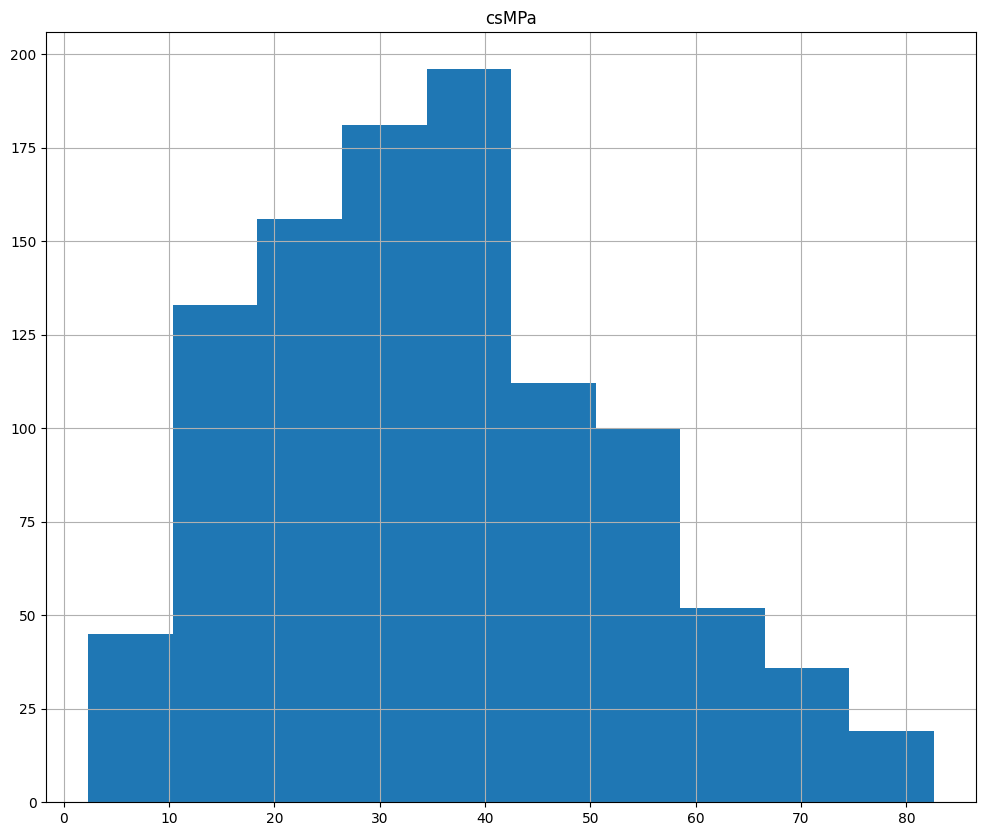

In [3]:
data.hist(column='csMPa', figsize=(12, 10))
mean_value = data['csMPa'].mean()
std_value = data['csMPa'].std()
print("Mean: ", mean_value)
print("Standard Deviation: ", std_value)
"""
 - This distribution is skewed to the right, with a long tail towards higher values.
 - Most of the data is to the left (between 10 and 40 MPa).
 - The mean and standard deviation are reported below (35.8 and 16.7, respectively).
"""

'\n - Slag, superplasticizer, flyash, and age are heavily skewed to the right and contain many zeroes.\n - This might be the case because these are "optional" add-ons to the concrete mixes and are not \n  - as commonly-used or as fundamental/necessary as the other ingredients.\n'

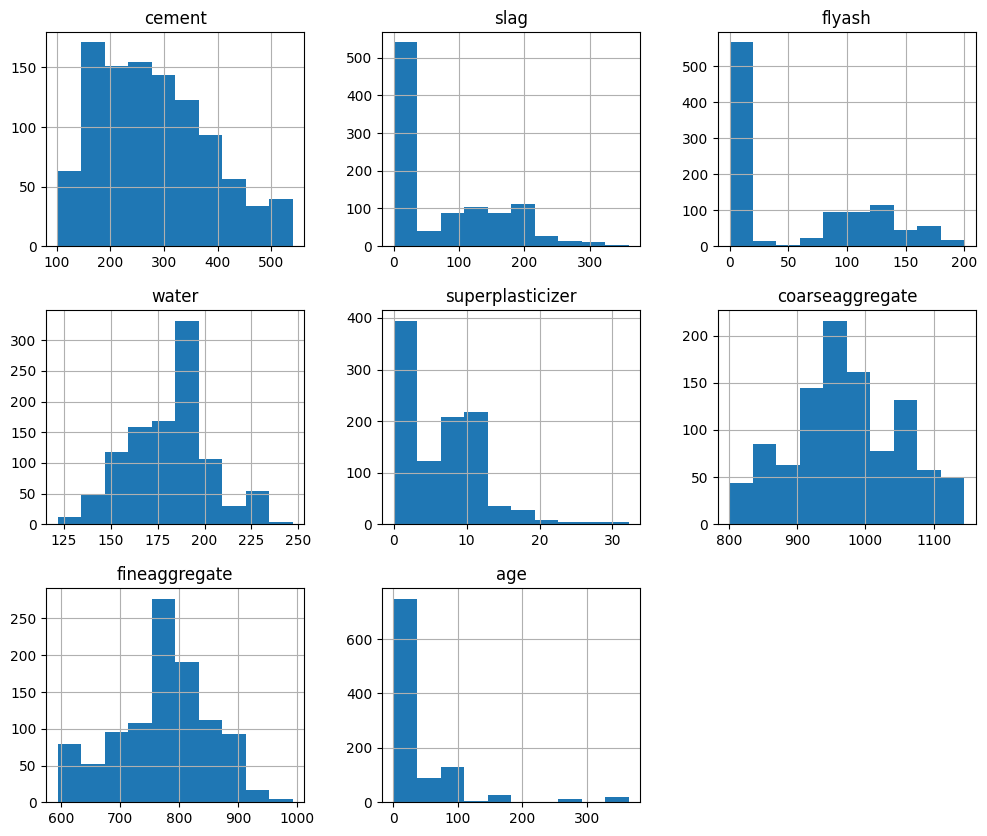

In [4]:
new_cols = data.columns[:-1] # exclude the target variable concrete strength
data.hist(column=new_cols, figsize=(12, 10))

"""
 - Slag, superplasticizer, flyash, and age are heavily skewed to the right and contain many zeroes.
 - This might be the case because these are "optional" add-ons to the concrete mixes and are not 
  - as commonly-used or as fundamental/necessary as the other ingredients.
"""

Pearson correlation between csMPa and cement: 0.4978
Pearson correlation between csMPa and slag: 0.1348
Pearson correlation between csMPa and flyash: -0.1058
Pearson correlation between csMPa and water: -0.2896
Pearson correlation between csMPa and superplasticizer: 0.3661
Pearson correlation between csMPa and coarseaggregate: -0.1649
Pearson correlation between csMPa and fineaggregate: -0.1672
Pearson correlation between csMPa and age: 0.3289


'\n - Cement amount is most positively correlated with strength.\n - Water amount is most negatively correlated with strength.\n - These relationships make sense because cement makes concrete stronger and harder, and water makes it \n  - weaker because the mixture becomes looser, wetter, and more moist.\n'

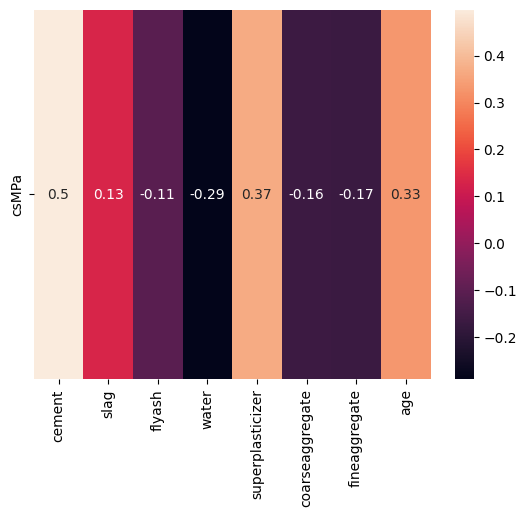

In [5]:
import math

# Pearson Correlation Matrix Calculation
pearson_coeffs = []
for col in data.columns[:-1]:  # Exclude the target variable
    a = np.corrcoef(data[col], data['csMPa'])[0, 1]
    pearson_coeffs.append(a)
    print(f"Pearson correlation between csMPa and {col}: {a:.4f}")

pearson_coeffs = np.array(pearson_coeffs).reshape(1, -1)  # Reshape for heatmap
sns.heatmap(pearson_coeffs, annot=True, xticklabels=data.columns[:-1], yticklabels=['csMPa'])

"""
 - Cement amount is most positively correlated with strength.
 - Water amount is most negatively correlated with strength.
 - These relationships make sense because cement makes concrete stronger and harder, and water makes it 
  - weaker because the mixture becomes looser, wetter, and more moist.
"""

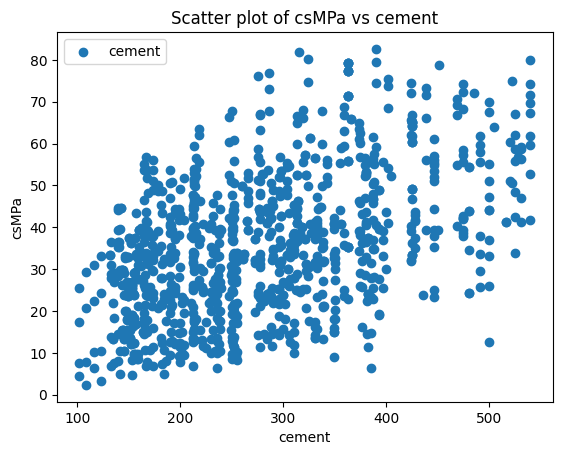

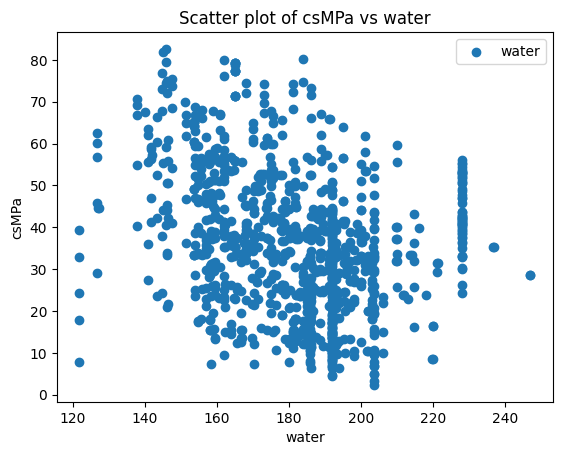

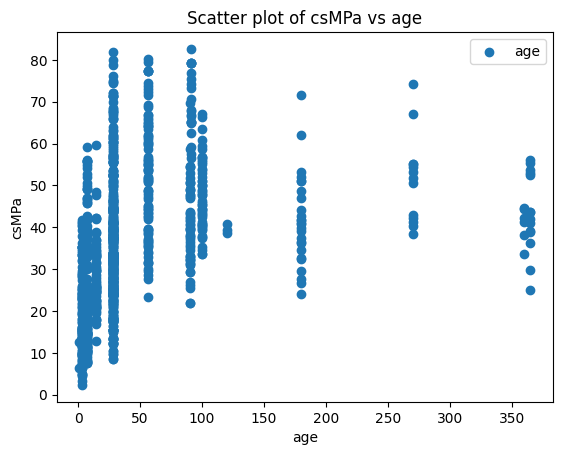

'\n- The relationships appear nonlinear, but there are positive correlations, and a linear relationship\n     - might be a reasonable approximation for these cases.\n'

In [6]:
for col in ['cement', 'water', 'age']:  # Exclude the target variable
    plt.scatter(data[col], data['csMPa'], label=col)
    plt.xlabel(col)
    plt.ylabel('csMPa')
    plt.title(f'Scatter plot of csMPa vs {col}')
    plt.legend()
    plt.show()

"""
- The relationships appear nonlinear, but there are positive correlations, and a linear relationship
     - might be a reasonable approximation for these cases.
"""


In [7]:
# randomly split the data into 80% training and 20% testing sets
np.random.seed(42) 

training_data = data.sample(frac=0.8)  # Sample 80% of the data for training   
    # Note that this uses the "global seed" that we set as 42 above
    # This helps with reproducibility
    
testing_data = data.drop(training_data.index)  # Use the remaining 20% for testing
print("Number of samples in training set:", training_data.shape[0])
print("Number of samples in testing set:", testing_data.shape[0])

Number of samples in training set: 824
Number of samples in testing set: 206


In [8]:
"""Why standardize the data?
Fitting linear regression directly on the raw features is problematic because the "slope"
for each feature's linear relationship will be much different from the others.
 - This means that it will be very difficult to do gradient descent due to the large
    differences in the scales of the slopes.
 - Standardizing the data brings these slopes much closer together than if they are
    left in their raw form, and this also allows for interpreting which features cause
    the most change easier (because they are all normalized).
"""

'Why standardize the data?\nFitting linear regression directly on the raw features is problematic because the "slope"\nfor each feature\'s linear relationship will be much different from the others.\n - This means that it will be very difficult to do gradient descent due to the large\n    differences in the scales of the slopes.\n - Standardizing the data brings these slopes much closer together than if they are\n    left in their raw form, and this also allows for interpreting which features cause\n    the most change easier (because they are all normalized).\n'

In [9]:
for col in data.columns[:-1]:  # Exclude the target variable
    mean = training_data[col].mean()
    std = training_data[col].std()
    
    training_data[col] = (training_data[col] - mean) / std
    testing_data[col] = (testing_data[col] - mean) / std

print("First 5 rows of the standardized training data:")
print(training_data.head())

"""
It would be incorrect to compute mean and variance on the combined train+test data because our model doesn't 
have (shouldn't have) access to the test data during training. The point of the test data is to 
evaluate whether we're overfitting or not, so using testing statistics makes our model worse 
and more likely to overfit later. 
"""

First 5 rows of the standardized training data:
       cement      slag    flyash     water  superplasticizer  \
31  -0.136386  0.493182 -0.857459  2.174267         -1.045332   
109  0.796535  1.384678 -0.857459 -0.740715          0.859627   
136  1.060187  1.384678 -0.857459 -1.618443          2.567522   
88   0.796535  1.384678 -0.857459 -0.740715          0.859627   
918 -1.304953 -0.861892  1.935831  0.973165          0.268433   

     coarseaggregate  fineaggregate       age  csMPa  
31         -0.511592      -1.315683  5.010859  52.91  
109        -0.350494      -0.257096 -0.600147  55.90  
136        -0.350494      -0.257096 -0.271009  74.50  
88         -0.350494      -0.257096 -0.662839  35.30  
918        -1.881562       1.139548 -0.271009  10.54  


"\nIt would be incorrect to compute mean and variance on the combined train+test data because our model doesn't \nhave (shouldn't have) access to the test data during training. The point of the test data is to \nevaluate whether we're overfitting or not, so using testing statistics makes our model worse \nand more likely to overfit later. \n"

In [10]:
print("\n---- TRAINING DATA STATISTICS: ")
for col in data.columns[:-1]:  # Exclude the target variable
    mean = training_data[col].mean()
    std = training_data[col].std()
    print(f"After standardization, mean of {col}: {training_data[col].mean():.4f}, std of {col}: {training_data[col].std():.4f}")

print("\n---- TESTING DATA STATISTICS: ")

for col in data.columns[:-1]:  # Exclude the target variable
    test_mean = testing_data[col].mean()
    test_std = testing_data[col].std()
    print(f"After standardization, mean of {col} in test set: {test_mean:.4f}, std of {col} in test set: {test_std:.4f}")

"""
The test set statistics are NOT exactly 0 and 1 because to compute the mean and std that we 
used to normalize the dataset, we only used the training data. Therefore, on the training data,
this will cause the new mean and variance to be exactly 0 and 1, but on the test data, the mean
and variance will be close to, but not quite, 0 and 1 (they are approximately, but not exactly
the same as the training data).
"""


---- TRAINING DATA STATISTICS: 
After standardization, mean of cement: 0.0000, std of cement: 1.0000
After standardization, mean of slag: 0.0000, std of slag: 1.0000
After standardization, mean of flyash: 0.0000, std of flyash: 1.0000
After standardization, mean of water: -0.0000, std of water: 1.0000
After standardization, mean of superplasticizer: -0.0000, std of superplasticizer: 1.0000
After standardization, mean of coarseaggregate: -0.0000, std of coarseaggregate: 1.0000
After standardization, mean of fineaggregate: 0.0000, std of fineaggregate: 1.0000
After standardization, mean of age: -0.0000, std of age: 1.0000

---- TESTING DATA STATISTICS: 
After standardization, mean of cement in test set: 0.0505, std of cement in test set: 1.0471
After standardization, mean of slag in test set: 0.0824, std of slag in test set: 1.1222
After standardization, mean of flyash in test set: -0.0593, std of flyash in test set: 0.9943
After standardization, mean of water in test set: 0.1463, std o

'\nThe test set statistics are NOT exactly 0 and 1 because to compute the mean and std that we \nused to normalize the dataset, we only used the training data. Therefore, on the training data,\nthis will cause the new mean and variance to be exactly 0 and 1, but on the test data, the mean\nand variance will be close to, but not quite, 0 and 1 (they are approximately, but not exactly\nthe same as the training data).\n'

In [11]:
# LINEAR REGRESSION via normal equations

x_data = training_data.drop(columns=['csMPa'])
# x_data = x_data + np.ones((x_data.shape[0], 1))  # Add a column of 1's for the bias term
x_data.insert(8, 'bias', 1)
y_data = training_data['csMPa']

w_star = np.linalg.inv(x_data.T @ x_data) @ x_data.T @ y_data
print("Optimal weights (w*): \n", w_star)

features_in_order = dict(zip(x_data.columns, w_star))
print("\n---- FEATURES WITH WEIGHT MAGNITUDES: ")
for feature, weight in features_in_order.items():
    print(f"Feature: {feature}, Weight: {weight:.4f}")

Optimal weights (w*): 
 0    13.226065
1     9.488564
2     6.549568
3    -3.115060
4     1.349761
5     1.798775
6     1.841686
7     7.029051
8    35.876566
dtype: float64

---- FEATURES WITH WEIGHT MAGNITUDES: 
Feature: cement, Weight: 13.2261
Feature: slag, Weight: 9.4886
Feature: flyash, Weight: 6.5496
Feature: water, Weight: -3.1151
Feature: superplasticizer, Weight: 1.3498
Feature: coarseaggregate, Weight: 1.7988
Feature: fineaggregate, Weight: 1.8417
Feature: age, Weight: 7.0291
Feature: bias, Weight: 35.8766


In [12]:
# Report the training and test MSEs
def compute_mse(X, y, w):
    X_arr = X.to_numpy()
    y_arr = y.to_numpy()
    w_arr = np.asarray(w).reshape(-1)
    predictions = X_arr @ w_arr
    mse = np.mean((predictions - y_arr) ** 2)
    return mse

x_test = testing_data.drop(columns=['csMPa'])
x_test.insert(8, 'bias', 1)
y_test = testing_data['csMPa']

x_train = training_data.drop(columns=['csMPa'])
x_train.insert(8, 'bias', 1)
y_train = training_data['csMPa']

train_mse = compute_mse(x_train, y_train, w_star)
test_mse = compute_mse(x_test, y_test, w_star)
print("Training MSE: " + str(train_mse))
print("Test MSE: " + str(test_mse))

"""
Once again, the cement has the largest absolute weight.
This makes sense because cement is the most fundamental component of concrete.
The amount of cement makes the most difference in how strong concrete is. 
"""

Training MSE: 107.79367936030673
Test MSE: 106.86456281099562


'\nOnce again, the cement has the largest absolute weight.\nThis makes sense because cement is the most fundamental component of concrete.\nThe amount of cement makes the most difference in how strong concrete is. \n'

In [13]:
# Problem 4(d)(i)
from itertools import combinations_with_replacement
from math import comb

feature_cols_q4 = list(data.columns[:-1])
X_train_base_q4 = training_data[feature_cols_q4].to_numpy(dtype=float)
X_test_base_q4 = testing_data[feature_cols_q4].to_numpy(dtype=float)
y_train_q4 = training_data["csMPa"].to_numpy(dtype=float)
y_test_q4 = testing_data["csMPa"].to_numpy(dtype=float)


def add_bias_q4(X):
    return np.column_stack([np.ones(X.shape[0]), X])


def polynomial_feature_matrix_q4(X, degree):
    columns = [np.ones(X.shape[0])]
    feature_names = ["1"]
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(X.shape[1]), deg):
            columns.append(np.prod(X[:, combo], axis=1))
            feature_names.append("*".join(feature_cols_q4[i] for i in combo))
    return np.column_stack(columns), feature_names


def fit_ols_q4(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y


def fit_ridge_q4(X, y, lam):
    return np.linalg.pinv(X.T @ X + lam * np.eye(X.shape[1])) @ X.T @ y


def mse_q4(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


X_train_linear_q4 = add_bias_q4(X_train_base_q4)
X_test_linear_q4 = add_bias_q4(X_test_base_q4)
w_linear_q4 = fit_ols_q4(X_train_linear_q4, y_train_q4)
linear_train_mse_q4 = mse_q4(y_train_q4, X_train_linear_q4 @ w_linear_q4)
linear_test_mse_q4 = mse_q4(y_test_q4, X_test_linear_q4 @ w_linear_q4)

q4_model_results = {
    "Linear (part c)": {
        "train_mse": linear_train_mse_q4,
        "test_mse": linear_test_mse_q4,
    }
}

num_features_deg2_q4 = comb(8 + 2, 2)
num_features_deg3_q4 = comb(8 + 3, 3)
print(f"Problem 4(d)(i): degree-2 expansion produces {num_features_deg2_q4} features.")
print(f"Problem 4(d)(i): degree-3 expansion produces {num_features_deg3_q4} features.")
print("These counts already include the constant term and all monomials up to the requested degree.")


Problem 4(d)(i): degree-2 expansion produces 45 features.
Problem 4(d)(i): degree-3 expansion produces 165 features.
These counts already include the constant term and all monomials up to the requested degree.


In [14]:
# Problem 4(d)(ii)
phi2_train_q4, phi2_feature_names_q4 = polynomial_feature_matrix_q4(X_train_base_q4, 2)
phi2_test_q4, _ = polynomial_feature_matrix_q4(X_test_base_q4, 2)

w_deg2_q4 = fit_ols_q4(phi2_train_q4, y_train_q4)
deg2_train_mse_q4 = mse_q4(y_train_q4, phi2_train_q4 @ w_deg2_q4)
deg2_test_mse_q4 = mse_q4(y_test_q4, phi2_test_q4 @ w_deg2_q4)

q4_model_results["Polynomial degree 2"] = {
    "train_mse": deg2_train_mse_q4,
    "test_mse": deg2_test_mse_q4,
}

print(f"Problem 4(d)(ii): degree-2 feature matrix shape = {phi2_train_q4.shape} for training and {phi2_test_q4.shape} for test.")
print(f"Training MSE (degree 2): {deg2_train_mse_q4:.4f}")
print(f"Test MSE (degree 2): {deg2_test_mse_q4:.4f}")
print(f"Compared with part (c), the test MSE drops from {linear_test_mse_q4:.4f} to {deg2_test_mse_q4:.4f}, so the quadratic expansion helps a lot on this split.")


Problem 4(d)(ii): degree-2 feature matrix shape = (824, 45) for training and (206, 45) for test.
Training MSE (degree 2): 51.9073
Test MSE (degree 2): 59.6819
Compared with part (c), the test MSE drops from 106.8646 to 59.6819, so the quadratic expansion helps a lot on this split.


In [15]:
# Problem 4(d)(iii)
phi3_train_q4, phi3_feature_names_q4 = polynomial_feature_matrix_q4(X_train_base_q4, 3)
phi3_test_q4, _ = polynomial_feature_matrix_q4(X_test_base_q4, 3)

w_deg3_q4 = fit_ols_q4(phi3_train_q4, y_train_q4)
deg3_train_mse_q4 = mse_q4(y_train_q4, phi3_train_q4 @ w_deg3_q4)
deg3_test_mse_q4 = mse_q4(y_test_q4, phi3_test_q4 @ w_deg3_q4)

q4_model_results["Polynomial degree 3"] = {
    "train_mse": deg3_train_mse_q4,
    "test_mse": deg3_test_mse_q4,
}

print(f"Problem 4(d)(iii): degree-3 feature matrix shape = {phi3_train_q4.shape} for training and {phi3_test_q4.shape} for test.")
print(f"Training MSE (degree 3): {deg3_train_mse_q4:.4f}")
print(f"Test MSE (degree 3): {deg3_test_mse_q4:.4f}")
print(f"Relative to degree 2, the training MSE drops from {deg2_train_mse_q4:.4f} to {deg3_train_mse_q4:.4f}, and the test MSE also drops from {deg2_test_mse_q4:.4f} to {deg3_test_mse_q4:.4f}.")
print("So on this split the cubic model is more expressive without hurting generalization, although the larger train/test gap still suggests higher variance than the simpler models.")


Problem 4(d)(iii): degree-3 feature matrix shape = (824, 165) for training and (206, 165) for test.
Training MSE (degree 3): 19.7206
Test MSE (degree 3): 35.6131
Relative to degree 2, the training MSE drops from 51.9073 to 19.7206, and the test MSE also drops from 59.6819 to 35.6131.
So on this split the cubic model is more expressive without hurting generalization, although the larger train/test gap still suggests higher variance than the simpler models.


In [16]:
# Problem 4(e)(i)
ridge_lambdas_q4 = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100], dtype=float)
ridge_rows_q4 = []

for lam in ridge_lambdas_q4:
    w_ridge = fit_ridge_q4(phi3_train_q4, y_train_q4, lam)
    ridge_rows_q4.append({
        "lambda": lam,
        "log10_lambda": np.log10(lam),
        "train_mse": mse_q4(y_train_q4, phi3_train_q4 @ w_ridge),
        "test_mse": mse_q4(y_test_q4, phi3_test_q4 @ w_ridge),
        "weight_l2_norm": np.linalg.norm(w_ridge),
    })

ridge_results_q4 = pd.DataFrame(ridge_rows_q4)
best_ridge_row_q4 = ridge_results_q4.loc[ridge_results_q4["test_mse"].idxmin()]

q4_model_results[f"Ridge degree 3 (lambda={best_ridge_row_q4['lambda']:.4g})"] = {
    "train_mse": float(best_ridge_row_q4["train_mse"]),
    "test_mse": float(best_ridge_row_q4["test_mse"]),
}

print("Problem 4(e)(i): ridge sweep on degree-3 polynomial features")
print(ridge_results_q4[["lambda", "train_mse", "test_mse"]].to_string(index=False))


Problem 4(e)(i): ridge sweep on degree-3 polynomial features
  lambda  train_mse  test_mse
  0.0001  19.720662 35.564802
  0.0010  19.726652 35.209208
  0.0100  19.843447 34.099571
  0.1000  20.186453 33.568049
  1.0000  21.378769 33.834392
 10.0000  29.138843 43.235709
100.0000  74.748303 88.840251


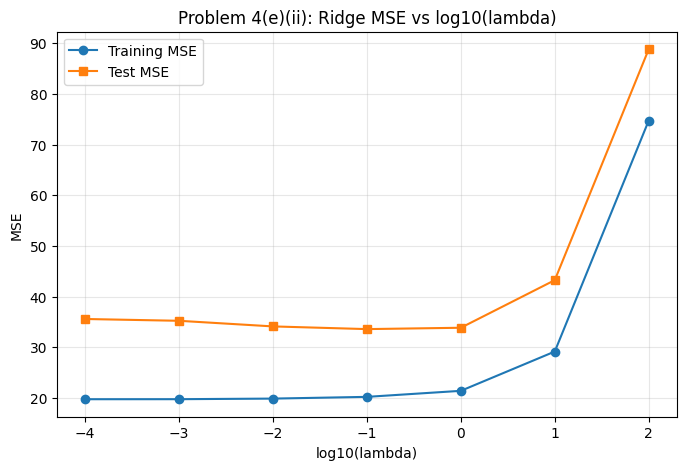

The plot shows the usual trade-off: a little regularization helps, but too much eventually drives both errors back up.


In [17]:
# Problem 4(e)(ii)
plt.figure(figsize=(8, 5))
plt.plot(ridge_results_q4["log10_lambda"], ridge_results_q4["train_mse"], marker="o", label="Training MSE")
plt.plot(ridge_results_q4["log10_lambda"], ridge_results_q4["test_mse"], marker="s", label="Test MSE")
plt.xlabel("log10(lambda)")
plt.ylabel("MSE")
plt.title("Problem 4(e)(ii): Ridge MSE vs log10(lambda)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("The plot shows the usual trade-off: a little regularization helps, but too much eventually drives both errors back up.")


In [18]:
# Problem 4(e)(iii)
best_ridge_lambda_q4 = float(best_ridge_row_q4["lambda"])
best_ridge_train_mse_q4 = float(best_ridge_row_q4["train_mse"])
best_ridge_test_mse_q4 = float(best_ridge_row_q4["test_mse"])

print(f"Problem 4(e)(iii): the test MSE is minimized at lambda = {best_ridge_lambda_q4:.4g}.")
print(f"Best ridge training MSE: {best_ridge_train_mse_q4:.4f}")
print(f"Best ridge test MSE: {best_ridge_test_mse_q4:.4f}")
print(f"Unregularized degree-3 test MSE: {deg3_test_mse_q4:.4f}")
print(f"Linear-model test MSE from part (c): {linear_test_mse_q4:.4f}")
print("Conclusion: a moderate amount of regularization improves the cubic model by reducing variance while keeping most of its nonlinear flexibility, which is exactly the bias-variance trade-off in action.")


Problem 4(e)(iii): the test MSE is minimized at lambda = 0.1.
Best ridge training MSE: 20.1865
Best ridge test MSE: 33.5680
Unregularized degree-3 test MSE: 35.6131
Linear-model test MSE from part (c): 106.8646
Conclusion: a moderate amount of regularization improves the cubic model by reducing variance while keeping most of its nonlinear flexibility, which is exactly the bias-variance trade-off in action.


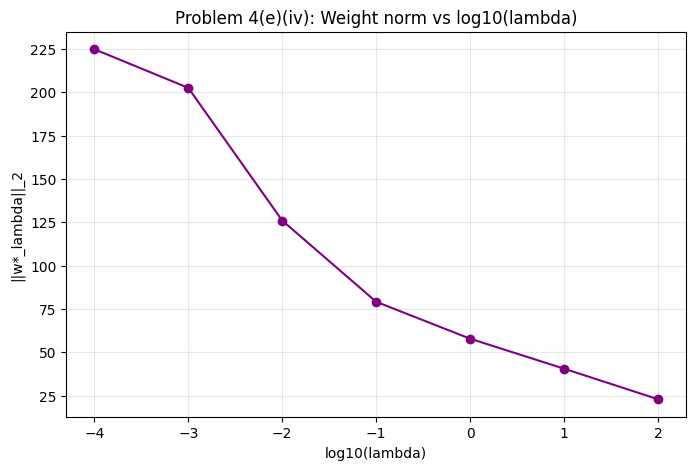

As lambda increases, the weight norm shrinks steadily.
That matches the augmented least-squares view from Problem 3: ridge acts like extra synthetic constraints that keep the solution closer to zero, so the model cannot lean too hard on any one polynomial term.


In [19]:
# Problem 4(e)(iv)
plt.figure(figsize=(8, 5))
plt.plot(ridge_results_q4["log10_lambda"], ridge_results_q4["weight_l2_norm"], marker="o", color="purple")
plt.xlabel("log10(lambda)")
plt.ylabel("||w*_lambda||_2")
plt.title("Problem 4(e)(iv): Weight norm vs log10(lambda)")
plt.grid(True, alpha=0.3)
plt.show()

print("As lambda increases, the weight norm shrinks steadily.")
print("That matches the augmented least-squares view from Problem 3: ridge acts like extra synthetic constraints that keep the solution closer to zero, so the model cannot lean too hard on any one polynomial term.")


In [20]:
# Problem 4(f)(i)
fold_indices_q4 = np.array_split(np.arange(X_train_base_q4.shape[0]), 5)
cv_rows_q4 = []

for lam in ridge_lambdas_q4:
    fold_mses = []
    for fold_id, val_idx in enumerate(fold_indices_q4):
        train_idx = np.concatenate([fold_indices_q4[j] for j in range(5) if j != fold_id])
        X_fold_train = X_train_base_q4[train_idx]
        y_fold_train = y_train_q4[train_idx]
        X_fold_val = X_train_base_q4[val_idx]
        y_fold_val = y_train_q4[val_idx]

        phi3_train_fold, _ = polynomial_feature_matrix_q4(X_fold_train, 3)
        phi3_val_fold, _ = polynomial_feature_matrix_q4(X_fold_val, 3)
        w_fold = fit_ridge_q4(phi3_train_fold, y_fold_train, lam)
        fold_mses.append(mse_q4(y_fold_val, phi3_val_fold @ w_fold))

    cv_rows_q4.append({
        "lambda": lam,
        "log10_lambda": np.log10(lam),
        "mean_validation_mse": float(np.mean(fold_mses)),
    })

cv_results_q4 = pd.DataFrame(cv_rows_q4)
print("Problem 4(f)(i): 5-fold cross-validation mean validation MSE")
print(cv_results_q4[["lambda", "mean_validation_mse"]].to_string(index=False))


Problem 4(f)(i): 5-fold cross-validation mean validation MSE
  lambda  mean_validation_mse
  0.0001            48.047498
  0.0010            47.793017
  0.0100            46.801458
  0.1000            44.228201
  1.0000            41.302015
 10.0000            49.319832
100.0000           103.568113


In [21]:
# Problem 4(f)(ii)
best_cv_row_q4 = cv_results_q4.loc[cv_results_q4["mean_validation_mse"].idxmin()]
best_cv_lambda_q4 = float(best_cv_row_q4["lambda"])
w_ridge_cv_best_q4 = fit_ridge_q4(phi3_train_q4, y_train_q4, best_cv_lambda_q4)
cv_selected_test_mse_q4 = mse_q4(y_test_q4, phi3_test_q4 @ w_ridge_cv_best_q4)

print(f"Problem 4(f)(ii): cross-validation chooses lambda = {best_cv_lambda_q4:.4g}.")
print(f"Mean validation MSE at that lambda: {float(best_cv_row_q4['mean_validation_mse']):.4f}")
print(f"Final test MSE after retraining on the full training set: {cv_selected_test_mse_q4:.4f}")
print(f"Single train/test split chose lambda = {best_ridge_lambda_q4:.4g} with test MSE {best_ridge_test_mse_q4:.4f}.")
print("The exact lambda is not identical here, but both procedures land in the same moderate-regularization regime and lead to very similar conclusions about the value of ridge regression.")


Problem 4(f)(ii): cross-validation chooses lambda = 1.
Mean validation MSE at that lambda: 41.3020
Final test MSE after retraining on the full training set: 33.8344
Single train/test split chose lambda = 0.1 with test MSE 33.5680.
The exact lambda is not identical here, but both procedures land in the same moderate-regularization regime and lead to very similar conclusions about the value of ridge regression.


In [22]:
# Problem 4(f)(iii)
print("Problem 4(f)(iii): the test set must stay outside cross-validation because it is supposed to simulate truly unseen data.")
print("If we repeatedly used the test set to choose lambda, we would gradually overfit our modeling decisions to that test set and the final reported test error would be too optimistic rather than an honest estimate of generalization.")


Problem 4(f)(iii): the test set must stay outside cross-validation because it is supposed to simulate truly unseen data.
If we repeatedly used the test set to choose lambda, we would gradually overfit our modeling decisions to that test set and the final reported test error would be too optimistic rather than an honest estimate of generalization.


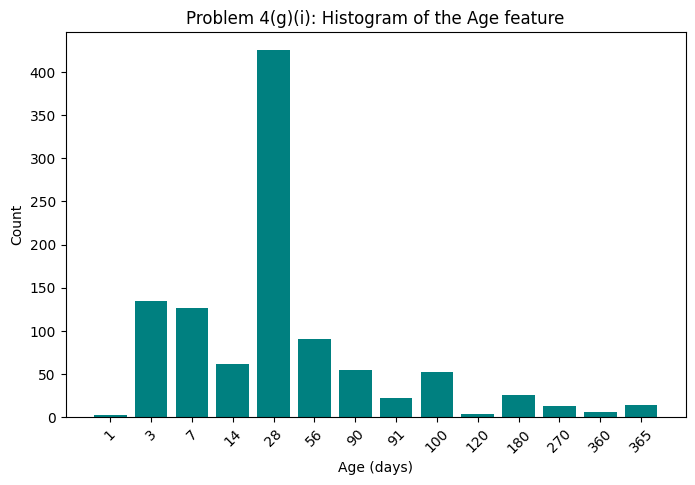

Problem 4(g)(i): the dataset contains 14 distinct age values.
Fraction of samples with Age = 28: 0.4126 (41.26%).
The histogram is heavily skewed because 28 days dominates the dataset relative to the rarer curing ages.


In [23]:
# Problem 4(g)(i)
age_counts_q4 = data["age"].value_counts().sort_index()
age_fraction_28_q4 = (data["age"] == 28).mean()

plt.figure(figsize=(8, 5))
plt.bar(age_counts_q4.index.astype(str), age_counts_q4.values, color="teal")
plt.xlabel("Age (days)")
plt.ylabel("Count")
plt.title("Problem 4(g)(i): Histogram of the Age feature")
plt.xticks(rotation=45)
plt.show()

print(f"Problem 4(g)(i): the dataset contains {age_counts_q4.shape[0]} distinct age values.")
print(f"Fraction of samples with Age = 28: {age_fraction_28_q4:.4f} ({age_fraction_28_q4 * 100:.2f}%).")
print("The histogram is heavily skewed because 28 days dominates the dataset relative to the rarer curing ages.")


In [24]:
# Problem 4(g)(ii)
train_age_original_q4 = data.loc[training_data.index, "age"].to_numpy()
age_value_counts_q4 = pd.Series(train_age_original_q4).value_counts().to_dict()
sample_weights_q4 = np.array([
    len(train_age_original_q4) / age_value_counts_q4[age]
    for age in train_age_original_q4
], dtype=float)
A_q4 = np.diag(sample_weights_q4)

w_weighted_q4 = np.linalg.pinv(X_train_linear_q4.T @ A_q4 @ X_train_linear_q4) @ (X_train_linear_q4.T @ A_q4 @ y_train_q4)
weighted_train_mse_q4 = mse_q4(y_train_q4, X_train_linear_q4 @ w_weighted_q4)
weighted_test_mse_q4 = mse_q4(y_test_q4, X_test_linear_q4 @ w_weighted_q4)

q4_model_results["Weighted linear"] = {
    "train_mse": weighted_train_mse_q4,
    "test_mse": weighted_test_mse_q4,
}

print(f"Problem 4(g)(ii): weighted linear training MSE = {weighted_train_mse_q4:.4f}")
print(f"Problem 4(g)(ii): weighted linear test MSE = {weighted_test_mse_q4:.4f}")
print(f"For comparison, the unweighted linear model from part (c) had training/test MSEs of {linear_train_mse_q4:.4f} / {linear_test_mse_q4:.4f}.")
print("Weighting hurts overall MSE on this split, which makes sense because overall MSE is dominated by the very common 28-day samples.")
print("A practitioner might still prefer the weighted model if accuracy on rare curing ages matters more than average performance, such as in early-strength or late-strength engineering decisions.")


Problem 4(g)(ii): weighted linear training MSE = 132.8530
Problem 4(g)(ii): weighted linear test MSE = 127.8295
For comparison, the unweighted linear model from part (c) had training/test MSEs of 107.7937 / 106.8646.
Weighting hurts overall MSE on this split, which makes sense because overall MSE is dominated by the very common 28-day samples.
A practitioner might still prefer the weighted model if accuracy on rare curing ages matters more than average performance, such as in early-strength or late-strength engineering decisions.


In [25]:
# Problem 4(h)
summary_rows_q4 = []
for model_name, metrics in q4_model_results.items():
    summary_rows_q4.append({
        "model": model_name,
        "train_mse": metrics["train_mse"],
        "test_mse": metrics["test_mse"],
    })

summary_table_q4 = pd.DataFrame(summary_rows_q4)
print("Problem 4(h): summary of all Problem 4 models")
print(summary_table_q4.to_string(index=False))
print()
print("Recommendation: on this split I would recommend the degree-3 ridge model because it gives the lowest test MSE while staying more controlled than the unregularized cubic fit.")
print("Regularization matters in the polynomial setting because it keeps the expanded feature space from producing large, unstable weights that chase noise.")
print("Weighted regression is still useful when the goal is fairer performance across rare age groups rather than the lowest average MSE, since the ordinary objective mostly reflects the dominant 28-day samples.")


Problem 4(h): summary of all Problem 4 models
                      model  train_mse   test_mse
            Linear (part c) 107.793679 106.864563
        Polynomial degree 2  51.907295  59.681921
        Polynomial degree 3  19.720582  35.613144
Ridge degree 3 (lambda=0.1)  20.186453  33.568049
            Weighted linear 132.852953 127.829464

Recommendation: on this split I would recommend the degree-3 ridge model because it gives the lowest test MSE while staying more controlled than the unregularized cubic fit.
Regularization matters in the polynomial setting because it keeps the expanded feature space from producing large, unstable weights that chase noise.
Weighted regression is still useful when the goal is fairer performance across rare age groups rather than the lowest average MSE, since the ordinary objective mostly reflects the dominant 28-day samples.


### Problem 5(a)(i)

In [26]:
# import question_5_data/train.csv and question_5_data/test.csv.
train_data = pd.read_csv("data/question_5_data/train.csv")
test_data = pd.read_csv("data/question_5_data/test.csv")

print("Shape of the training dataset:", train_data.shape)
print("Shape of the test dataset:", test_data.shape)

Shape of the training dataset: (8693, 14)
Shape of the test dataset: (4277, 13)


In [27]:
print("Column names in the training dataset:", train_data.columns)
print("---------------------\nData types in the training dataset:\n", train_data.dtypes)

Column names in the training dataset: Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')
---------------------
Data types in the training dataset:
 PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object


In [28]:
# Display the first five rows
print("First five rows of the training dataset:\n", train_data.head())

First five rows of the training dataset:
   PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        Fa

 - 6 features are numerical and the rest (8) are categorical. 
Note that I'm counting the PassengerID as one of the categorical features (it shouldn't make a difference in the model).

### Problem 5(a)(ii)

In [29]:
# report the number and percent of missing values in each column
missing_values_count = train_data.isnull().sum()
total_rows = train_data.shape[0]
missing_values_percent = (missing_values_count / total_rows) * 100

print("Missing values in each column:")
print(missing_values_count)

Missing values in each column:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [30]:
print("\nPercentage of missing values in each column:")
print(missing_values_percent)


Percentage of missing values in each column:
PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64


<BarContainer object of 14 artists>

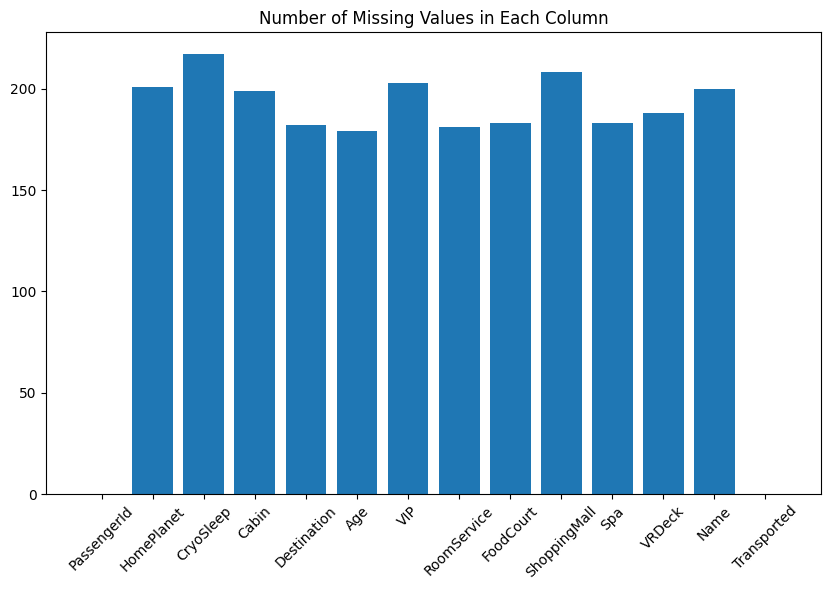

In [31]:
# display the results as a table or bar chart
plt.figure(figsize=(10, 6))
plt.xticks(rotation=45)
plt.title("Number of Missing Values in Each Column")
plt.bar(missing_values_count.index, missing_values_count.values)

 - HomePlanet has the most missing data, followed by ShoppingMall, VIP, Cabin, PassengerID, and Name. 
 - The missing values are spread throughout. 
 - Bar chart of results is shown above.

### Problem 5(a)(iii)

In [32]:
# split train.csv into 60% train, 20% validation, and 20% test using np.random.seed(42)
np.random.seed(42)

# first split: 80% train+validation, 20% test
train_val_split = train_data.sample(frac=0.8, random_state=42)
test_split = train_data.drop(train_val_split.index).copy()

# second split: 75%/25% of the remaining 80%, giving 60% train and 20% validation overall
train_split = train_val_split.sample(frac=0.75, random_state=42)
validation_split = train_val_split.drop(train_split.index).copy()
train_split = train_split.copy()

for split_name, split_df in [('Train', train_split), ('Validation', validation_split), ('Test', test_split)]:
    transported_fraction = split_df['Transported'].mean()
    print(f"{split_name} set size: {len(split_df)}")
    print(f"{split_name} transported fraction: {transported_fraction:.4f} ({transported_fraction * 100:.2f}%)")

Train set size: 5216
Train transported fraction: 0.5065 (50.65%)
Validation set size: 1738
Validation transported fraction: 0.4885 (48.85%)
Test set size: 1739
Test transported fraction: 0.5101 (51.01%)


 - The dataset is roughly balanced because there are about half that were transported and half that were not.

### Problem 5(a)(iv)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RoomService'}>],
       [<Axes: title={'center': 'FoodCourt'}>,
        <Axes: title={'center': 'ShoppingMall'}>],
       [<Axes: title={'center': 'Spa'}>,
        <Axes: title={'center': 'VRDeck'}>]], dtype=object)

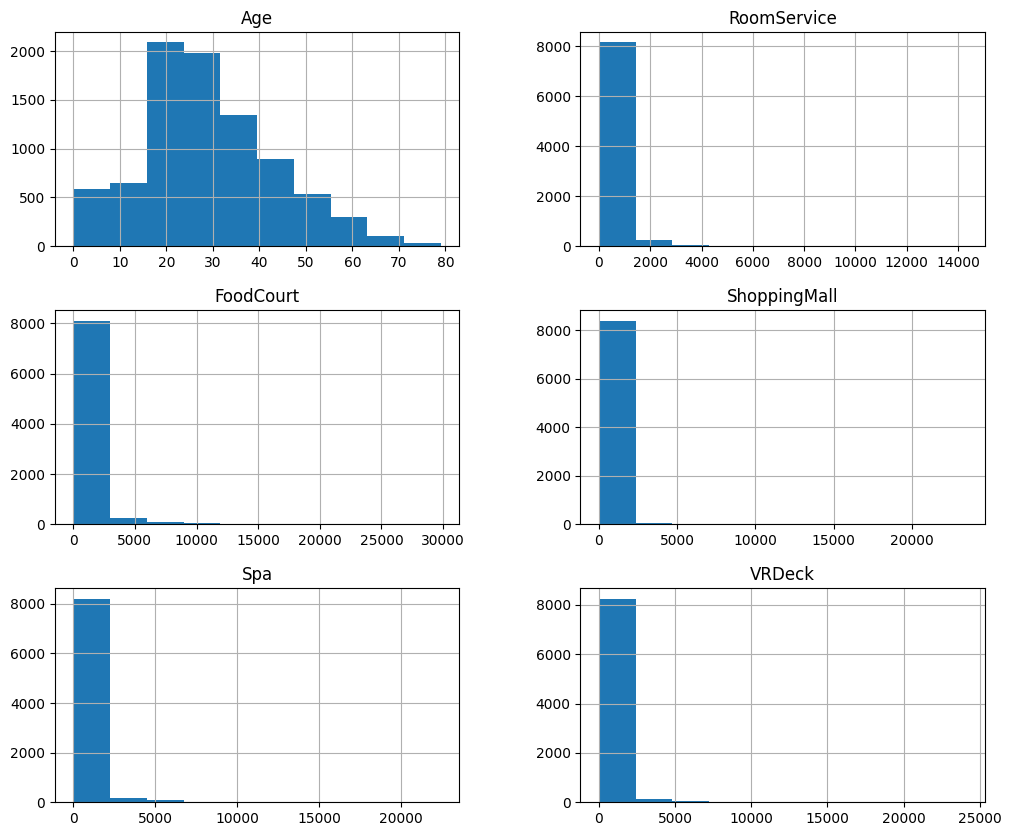

In [33]:
# plot histograms of all numerical features
numerical_cols = train_data.select_dtypes(include=['float64', 'int64']).columns
train_data[numerical_cols].hist(figsize=(12, 10))

 - All of them, except for Age, are heavily right skewed. Age is still right-skewed but to a lesser degree.
 - The fact that most passengers have spending values near zero tells us that most passengers are low-class or middle-class, while there are very few outliers or rich people that have high spending bills.

### Problem 5(a)(v)

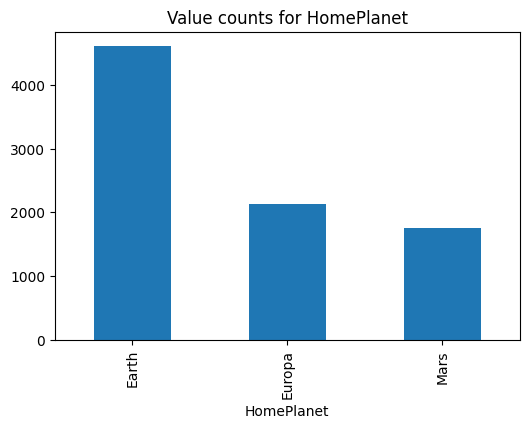

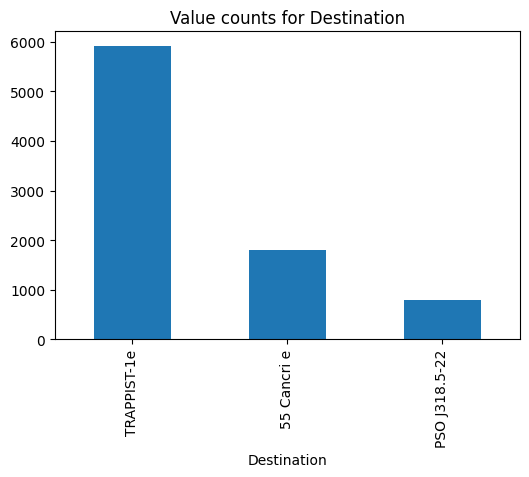

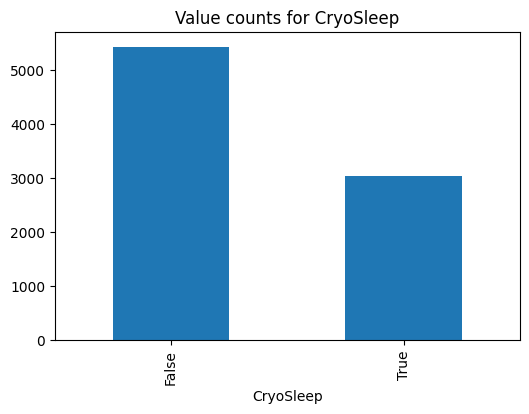

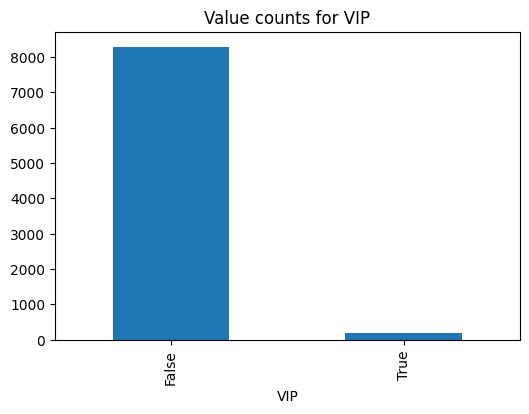

In [34]:
# plot bar chart of HomePlanet, Destination, CryoSleep, and VIP vs how many of their values are NOT null
categorical_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']
for i in categorical_cols:
    plt.figure(figsize=(6, 4))
    train_data[i].value_counts().plot(kind='bar')
    plt.title(f"Value counts for {i}")

In [35]:
# print the fraction of those from each category that were transported
for col in categorical_cols:
    transported_fractions = train_data.groupby(col)['Transported'].mean()
    print(f"-----------\nTransported fractions by {col}:")
    print(transported_fractions)

-----------
Transported fractions by HomePlanet:
HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64
-----------
Transported fractions by Destination:
Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64
-----------
Transported fractions by CryoSleep:
CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64
-----------
Transported fractions by VIP:
VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64


 - The CryoSleep category seems like the most predictive of the target because it is the most binary and has the largest gap between the transportation rates.

### Problem 5(a)(vi)

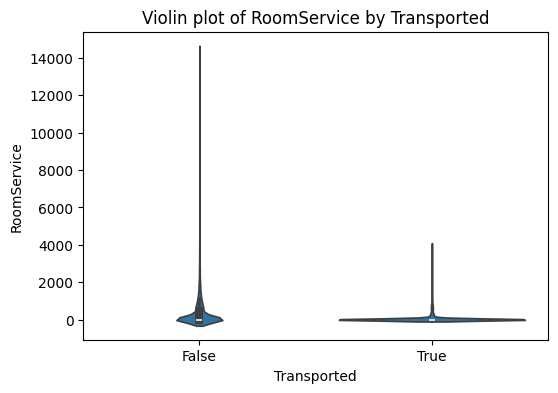

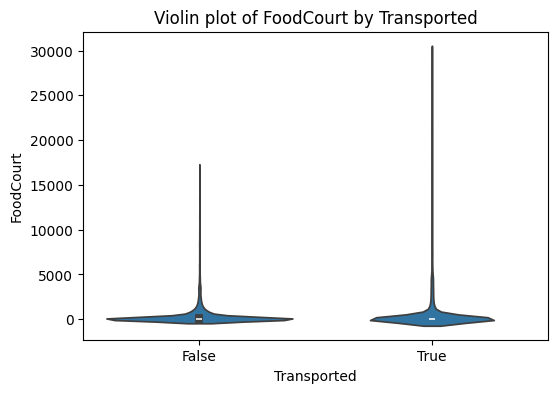

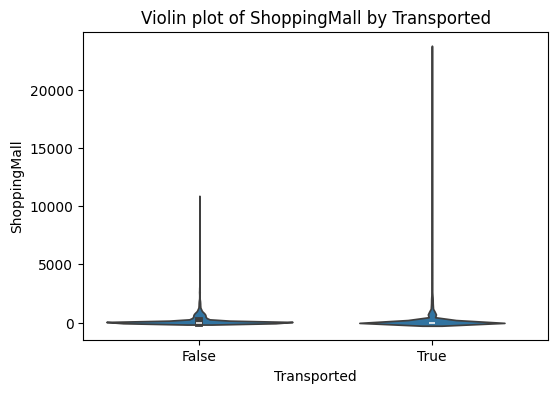

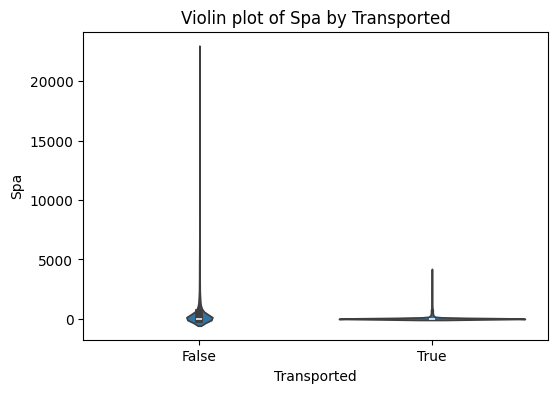

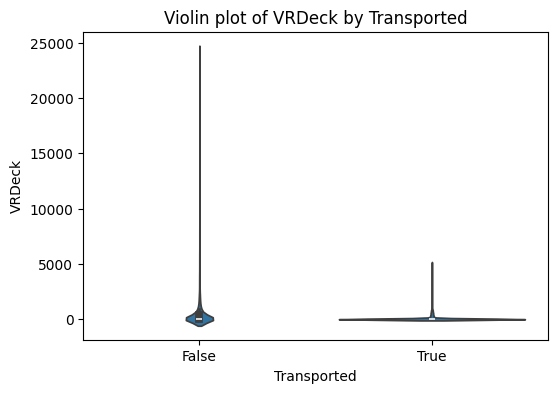

In [36]:
# create violin plot of each spending feature split
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='Transported', y=col, data=train_data)
    plt.title(f"Violin plot of {col} by Transported")

 - Transported passengers tend to spend less.
 - A hypothesis for this is that because many of the transported passengers were in cryogenic sleep, they could not visit the mall or food court or use the VR technology, so they spent less money by not using those.

### Problem 5(b)(i)

In [37]:
# remove passengerId, Name, and Cabin columns from the training and test datasets
train_data = train_data.drop(columns=['PassengerId', 'Name', 'Cabin'])
test_data = test_data.drop(columns=['PassengerId', 'Name', 'Cabin'])
print("This cell has been run.")

This cell has been run.


 - PassengerID and Name are not directly useful for logistic regression because they only serve as indexing tools to "label" a certain passenger and distinguish between different passengers.
 - Cabin is not useful because these don't have any correlation with whether a passenger was transported or not; it, again, is a distinguisher to help categorize different passengers by where they live, and nothing more.

### Problem 5(b)(ii)

In [38]:
# for HomePlanet, Destination, CryoSleep, and VIP, insert the mode into every missing value
for col in categorical_cols:
    mode_value = train_data[col].mode()[0]
    train_data[col] = train_data[col].fillna(mode_value)
print("Finished running this cell.")

Finished running this cell.


### Problem 5(b)(iii)

In [39]:
for col in numerical_cols:
    # compute the mean of the column in the training data
    mean_value = train_data[col].mean()
    train_data[col] = train_data[col].fillna(mean_value)
print("Finished running this cell.")

Finished running this cell.


### Problem 5(b)(iv)

In [40]:
feature_cols_to_drop = ['PassengerId', 'Name', 'Cabin']
binary_cols = ['CryoSleep', 'VIP']
nominal_cols = ['HomePlanet', 'Destination']
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

def preprocess_split_data(train_df, validation_df, test_df):
    train_df = train_df.drop(columns=feature_cols_to_drop).copy()
    validation_df = validation_df.drop(columns=feature_cols_to_drop).copy()
    test_df = test_df.drop(columns=feature_cols_to_drop).copy()

    categorical_cols = nominal_cols + binary_cols
    for col in categorical_cols:
        mode_value = train_df[col].mode()[0]
        train_df[col] = train_df[col].fillna(mode_value)
        validation_df[col] = validation_df[col].fillna(mode_value)
        test_df[col] = test_df[col].fillna(mode_value)

    for col in numerical_cols:
        mean_value = train_df[col].mean()
        train_df[col] = train_df[col].fillna(mean_value)
        validation_df[col] = validation_df[col].fillna(mean_value)
        test_df[col] = test_df[col].fillna(mean_value)

    for col in binary_cols:
        train_df[col] = train_df[col].astype(int)
        validation_df[col] = validation_df[col].astype(int)
        test_df[col] = test_df[col].astype(int)

    y_train = train_df['Transported'].astype(int)
    y_validation = validation_df['Transported'].astype(int)
    y_test = test_df['Transported'].astype(int)

    X_train = train_df.drop(columns=['Transported'])
    X_validation = validation_df.drop(columns=['Transported'])
    X_test = test_df.drop(columns=['Transported'])

    X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=int)
    X_validation = pd.get_dummies(X_validation, columns=nominal_cols, drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=int)

    X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    return X_train, y_train, X_validation, y_validation, X_test, y_test

X_train, y_train, X_validation, y_validation, X_test, y_test = preprocess_split_data(
    train_split, validation_split, test_split
)

print("X_train shape:", X_train.shape)
print("X_validation shape:", X_validation.shape)
print("X_test shape:", X_test.shape)
print("Any missing values left in X_train?", X_train.isnull().any().any())
print("Finished running this cell.")

X_train shape: (5216, 12)
X_validation shape: (1738, 12)
X_test shape: (1739, 12)
Any missing values left in X_train? False
Finished running this cell.


In [41]:
# Problem 5(c)(i)
from itertools import combinations_with_replacement
from pathlib import Path

if 'train_data' not in globals():
    p5_train_csv = Path('data/question_5_data/train.csv')
    if not p5_train_csv.exists():
        p5_train_csv = Path('hw1/data/question_5_data/train.csv')
    train_data = pd.read_csv(p5_train_csv)

if 'train_split' not in globals() or 'validation_split' not in globals() or 'test_split' not in globals():
    np.random.seed(42)
    train_val_split = train_data.sample(frac=0.8, random_state=42)
    test_split = train_data.drop(train_val_split.index).copy()
    train_split = train_val_split.sample(frac=0.75, random_state=42)
    validation_split = train_val_split.drop(train_split.index).copy()

p5_feature_cols_to_drop = ['PassengerId', 'Name', 'Cabin']
p5_binary_cols = ['CryoSleep', 'VIP']
p5_nominal_cols = ['HomePlanet', 'Destination']
p5_numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
p5_spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
p5_lambda_grid = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]


def p5_prepare_base_splits(train_df, validation_df, test_df):
    train_df = train_df.drop(columns=p5_feature_cols_to_drop).copy()
    validation_df = validation_df.drop(columns=p5_feature_cols_to_drop).copy()
    test_df = test_df.drop(columns=p5_feature_cols_to_drop).copy()

    for col in p5_nominal_cols + p5_binary_cols:
        mode_value = train_df[col].mode()[0]
        train_df[col] = train_df[col].fillna(mode_value)
        validation_df[col] = validation_df[col].fillna(mode_value)
        test_df[col] = test_df[col].fillna(mode_value)

    for col in p5_numerical_cols:
        mean_value = train_df[col].mean()
        train_df[col] = train_df[col].fillna(mean_value)
        validation_df[col] = validation_df[col].fillna(mean_value)
        test_df[col] = test_df[col].fillna(mean_value)

    for col in p5_binary_cols:
        train_df[col] = train_df[col].astype(int)
        validation_df[col] = validation_df[col].astype(int)
        test_df[col] = test_df[col].astype(int)

    y_train = train_df['Transported'].astype(int).to_numpy(dtype=float)
    y_validation = validation_df['Transported'].astype(int).to_numpy(dtype=float)
    y_test = test_df['Transported'].astype(int).to_numpy(dtype=float)

    X_train = pd.get_dummies(train_df.drop(columns=['Transported']), columns=p5_nominal_cols, drop_first=True, dtype=int)
    X_validation = pd.get_dummies(validation_df.drop(columns=['Transported']), columns=p5_nominal_cols, drop_first=True, dtype=int)
    X_test = pd.get_dummies(test_df.drop(columns=['Transported']), columns=p5_nominal_cols, drop_first=True, dtype=int)

    X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    train_mean = X_train.mean()
    train_std = X_train.std().replace(0, 1)
    X_train = (X_train - train_mean) / train_std
    X_validation = (X_validation - train_mean) / train_std
    X_test = (X_test - train_mean) / train_std

    return X_train, y_train, X_validation, y_validation, X_test, y_test


def p5_add_engineered_features(X_train, X_validation, X_test, raw_train_df, raw_validation_df, raw_test_df):
    train_clean = raw_train_df.drop(columns=p5_feature_cols_to_drop).copy()
    validation_clean = raw_validation_df.drop(columns=p5_feature_cols_to_drop).copy()
    test_clean = raw_test_df.drop(columns=p5_feature_cols_to_drop).copy()

    for col in p5_nominal_cols + p5_binary_cols:
        mode_value = train_clean[col].mode()[0]
        train_clean[col] = train_clean[col].fillna(mode_value)
        validation_clean[col] = validation_clean[col].fillna(mode_value)
        test_clean[col] = test_clean[col].fillna(mode_value)

    for col in p5_numerical_cols:
        mean_value = train_clean[col].mean()
        train_clean[col] = train_clean[col].fillna(mean_value)
        validation_clean[col] = validation_clean[col].fillna(mean_value)
        test_clean[col] = test_clean[col].fillna(mean_value)

    for frame in (train_clean, validation_clean, test_clean):
        total_spending = frame[p5_spending_cols].sum(axis=1)
        frame['zero_total_spending'] = (total_spending == 0).astype(int)
        frame['log_total_spending_raw'] = np.log1p(total_spending)

    log_mean = train_clean['log_total_spending_raw'].mean()
    log_std = train_clean['log_total_spending_raw'].std()
    if log_std == 0:
        log_std = 1.0

    X_train = X_train.copy()
    X_validation = X_validation.copy()
    X_test = X_test.copy()
    X_train['zero_total_spending'] = train_clean['zero_total_spending'].to_numpy(dtype=float)
    X_validation['zero_total_spending'] = validation_clean['zero_total_spending'].to_numpy(dtype=float)
    X_test['zero_total_spending'] = test_clean['zero_total_spending'].to_numpy(dtype=float)
    X_train['log_total_spending'] = ((train_clean['log_total_spending_raw'] - log_mean) / log_std).to_numpy(dtype=float)
    X_validation['log_total_spending'] = ((validation_clean['log_total_spending_raw'] - log_mean) / log_std).to_numpy(dtype=float)
    X_test['log_total_spending'] = ((test_clean['log_total_spending_raw'] - log_mean) / log_std).to_numpy(dtype=float)
    return X_train, X_validation, X_test


def p5_add_spending_interactions(X_train, X_validation, X_test):
    interaction_pairs = list(combinations_with_replacement(p5_spending_cols, 2))
    X_train = X_train.copy()
    X_validation = X_validation.copy()
    X_test = X_test.copy()
    for left, right in interaction_pairs:
        feature_name = f'{left}*{right}'
        X_train[feature_name] = X_train[left] * X_train[right]
        X_validation[feature_name] = X_validation[left] * X_validation[right]
        X_test[feature_name] = X_test[left] * X_test[right]
    return X_train, X_validation, X_test, interaction_pairs


def p5_add_bias(X_df):
    return np.column_stack([np.ones(X_df.shape[0]), X_df.to_numpy(dtype=float)])


def p5_sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def p5_cross_entropy_loss(X, y, w):
    probs = np.clip(p5_sigmoid(X @ w), 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(probs) + (1 - y) * np.log(1 - probs))


def p5_cross_entropy_grad(X, y, w):
    probs = p5_sigmoid(X @ w)
    return (X.T @ (probs - y)) / len(y)


def p5_mse_loss(X, y, w):
    probs = p5_sigmoid(X @ w)
    return np.mean((probs - y) ** 2)


def p5_mse_grad(X, y, w):
    probs = p5_sigmoid(X @ w)
    return (2.0 / len(y)) * (X.T @ ((probs - y) * probs * (1 - probs)))


def p5_regularized_ce_loss(X, y, w, lam):
    return p5_cross_entropy_loss(X, y, w) + 0.5 * lam * np.sum(w ** 2)


def p5_regularized_ce_grad(X, y, w, lam):
    return p5_cross_entropy_grad(X, y, w) + lam * w


def p5_gradient_descent(X, y, grad_fn, loss_fn, lr=0.1, iterations=1000, lam=None):
    weights = np.zeros(X.shape[1])
    loss_history = []
    for _ in range(iterations):
        gradient = grad_fn(X, y, weights) if lam is None else grad_fn(X, y, weights, lam)
        weights -= lr * gradient
        current_loss = loss_fn(X, y, weights) if lam is None else loss_fn(X, y, weights, lam)
        loss_history.append(current_loss)
    return weights, np.array(loss_history)


def p5_accuracy(X, y, w):
    predictions = (p5_sigmoid(X @ w) >= 0.5).astype(int)
    return np.mean(predictions == y)


p5_X_train_base, p5_y_train, p5_X_validation_base, p5_y_validation, p5_X_test_base, p5_y_test = p5_prepare_base_splits(
    train_split,
    validation_split,
    test_split,
)
p5_X_train_base_bias = p5_add_bias(p5_X_train_base)
p5_X_validation_base_bias = p5_add_bias(p5_X_validation_base)
p5_X_test_base_bias = p5_add_bias(p5_X_test_base)

print('Gradient of J_CE(w): (1/N) X^T (sigmoid(Xw) - y)')
print('For one example, grad ell_i(w) = (sigmoid(w^T x_i) - y_i) x_i, which matches Problem 2(c).')
print('Base feature matrix shape:', p5_X_train_base.shape)


Gradient of J_CE(w): (1/N) X^T (sigmoid(Xw) - y)
For one example, grad ell_i(w) = (sigmoid(w^T x_i) - y_i) x_i, which matches Problem 2(c).
Base feature matrix shape: (5216, 12)


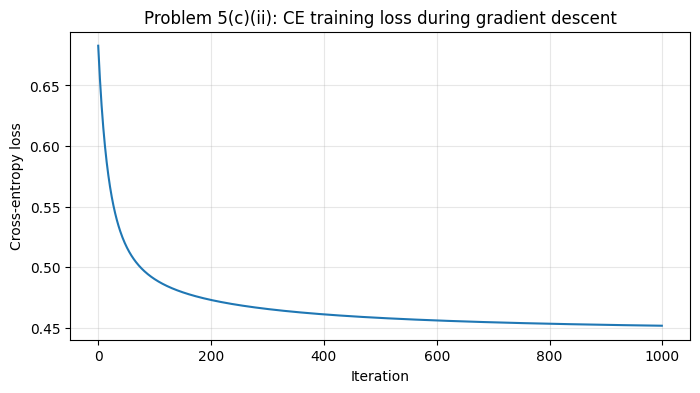

Initial loss: 0.6828
Final loss:   0.4517
The loss decreases smoothly and appears to converge.


In [42]:
# Problem 5(c)(ii)
p5_ce_weights, p5_ce_history = p5_gradient_descent(
    p5_X_train_base_bias,
    p5_y_train,
    p5_cross_entropy_grad,
    p5_cross_entropy_loss,
    lr=0.1,
    iterations=1000,
)

plt.figure(figsize=(8, 4))
plt.plot(p5_ce_history, color='tab:blue')
plt.xlabel('Iteration')
plt.ylabel('Cross-entropy loss')
plt.title('Problem 5(c)(ii): CE training loss during gradient descent')
plt.grid(alpha=0.3)
plt.show()

print(f'Initial loss: {p5_ce_history[0]:.4f}')
print(f'Final loss:   {p5_ce_history[-1]:.4f}')
print('The loss decreases smoothly and appears to converge.')


In [43]:
# Problem 5(c)(iii)
p5_ce_train_acc = p5_accuracy(p5_X_train_base_bias, p5_y_train, p5_ce_weights)
p5_ce_validation_acc = p5_accuracy(p5_X_validation_base_bias, p5_y_validation, p5_ce_weights)

print(f'Training accuracy:   {p5_ce_train_acc:.4f}')
print(f'Validation accuracy: {p5_ce_validation_acc:.4f}')


Training accuracy:   0.7837
Validation accuracy: 0.7745


In [44]:
# Problem 5(d)(i)
print('Gradient of J_MSE(w): (2/N) X^T[(sigmoid(Xw) - y) * sigmoid(Xw) * (1 - sigmoid(Xw))]')
print('Compared with cross-entropy, the extra multiplicative factor is sigmoid(Xw) * (1 - sigmoid(Xw)).')


Gradient of J_MSE(w): (2/N) X^T[(sigmoid(Xw) - y) * sigmoid(Xw) * (1 - sigmoid(Xw))]
Compared with cross-entropy, the extra multiplicative factor is sigmoid(Xw) * (1 - sigmoid(Xw)).


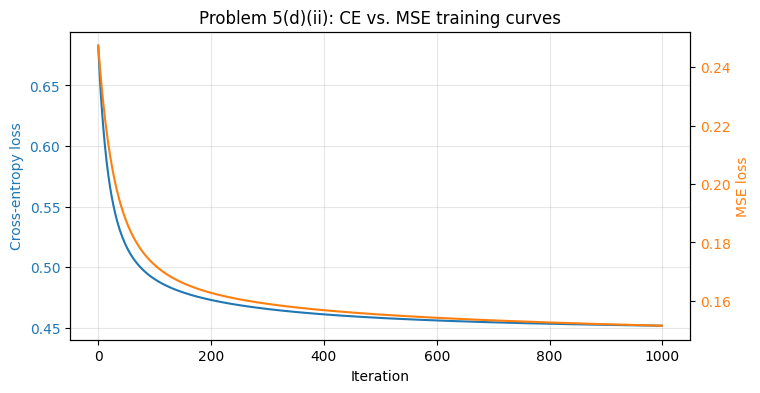

Final CE loss:  0.4517
Final MSE loss: 0.1515


In [45]:
# Problem 5(d)(ii)
p5_mse_weights, p5_mse_history = p5_gradient_descent(
    p5_X_train_base_bias,
    p5_y_train,
    p5_mse_grad,
    p5_mse_loss,
    lr=0.1,
    iterations=1000,
)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(p5_ce_history, color='tab:blue', label='CE loss')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cross-entropy loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(p5_mse_history, color='tab:orange', label='MSE loss')
ax2.set_ylabel('MSE loss', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Problem 5(d)(ii): CE vs. MSE training curves')
plt.show()

print(f'Final CE loss:  {p5_ce_history[-1]:.4f}')
print(f'Final MSE loss: {p5_mse_history[-1]:.4f}')


In [46]:
# Problem 5(d)(iii)
p5_mse_train_acc = p5_accuracy(p5_X_train_base_bias, p5_y_train, p5_mse_weights)
p5_mse_validation_acc = p5_accuracy(p5_X_validation_base_bias, p5_y_validation, p5_mse_weights)

print(f'Training accuracy (MSE):   {p5_mse_train_acc:.4f}')
print(f'Validation accuracy (MSE): {p5_mse_validation_acc:.4f}')
print(f'Training accuracy (CE):    {p5_ce_train_acc:.4f}')
print(f'Validation accuracy (CE):  {p5_ce_validation_acc:.4f}')
print('Performance is similar on validation, but CE converges more directly and gives a slightly better training fit, which is consistent with the vanishing-gradient issue for MSE.')


Training accuracy (MSE):   0.7809
Validation accuracy (MSE): 0.7745
Training accuracy (CE):    0.7837
Validation accuracy (CE):  0.7745
Performance is similar on validation, but CE converges more directly and gives a slightly better training fit, which is consistent with the vanishing-gradient issue for MSE.


In [47]:
# Problem 5(e)(i)
p5_X_train_engineered, p5_X_validation_engineered, p5_X_test_engineered = p5_add_engineered_features(
    p5_X_train_base,
    p5_X_validation_base,
    p5_X_test_base,
    train_split,
    validation_split,
    test_split,
)

p5_X_train_engineered_bias = p5_add_bias(p5_X_train_engineered)
p5_X_validation_engineered_bias = p5_add_bias(p5_X_validation_engineered)
p5_X_test_engineered_bias = p5_add_bias(p5_X_test_engineered)

p5_engineered_weights, p5_engineered_history = p5_gradient_descent(
    p5_X_train_engineered_bias,
    p5_y_train,
    p5_cross_entropy_grad,
    p5_cross_entropy_loss,
    lr=0.1,
    iterations=1000,
)

p5_engineered_validation_acc = p5_accuracy(p5_X_validation_engineered_bias, p5_y_validation, p5_engineered_weights)

print('Added features: zero_total_spending and log_total_spending')
print(f'Validation accuracy with engineered totals: {p5_engineered_validation_acc:.4f}')
print(f'Baseline CE validation accuracy:            {p5_ce_validation_acc:.4f}')
print('The extra spending summary features do not improve validation accuracy on this split.')


Added features: zero_total_spending and log_total_spending
Validation accuracy with engineered totals: 0.7704
Baseline CE validation accuracy:            0.7745
The extra spending summary features do not improve validation accuracy on this split.


In [48]:
# Problem 5(e)(ii)
p5_X_train_interactions, p5_X_validation_interactions, p5_X_test_interactions, p5_interaction_pairs = p5_add_spending_interactions(
    p5_X_train_engineered,
    p5_X_validation_engineered,
    p5_X_test_engineered,
)

p5_X_train_interactions_bias = p5_add_bias(p5_X_train_interactions)
p5_X_validation_interactions_bias = p5_add_bias(p5_X_validation_interactions)
p5_X_test_interactions_bias = p5_add_bias(p5_X_test_interactions)

p5_interaction_weights, p5_interaction_history = p5_gradient_descent(
    p5_X_train_interactions_bias,
    p5_y_train,
    p5_cross_entropy_grad,
    p5_cross_entropy_loss,
    lr=0.05,
    iterations=1500,
)

p5_interaction_validation_acc = p5_accuracy(p5_X_validation_interactions_bias, p5_y_validation, p5_interaction_weights)

print(f'Number of new interaction features: {len(p5_interaction_pairs)}')
print(f'Total feature count after expansion: {p5_X_train_interactions.shape[1]}')
print(f'Validation accuracy with interactions: {p5_interaction_validation_acc:.4f}')


Number of new interaction features: 15
Total feature count after expansion: 29
Validation accuracy with interactions: 0.7727


In [49]:
# Problem 5(e)(iii)
print(f'Baseline CE validation accuracy:       {p5_ce_validation_acc:.4f}')
print(f'Engineered total-spending accuracy:    {p5_engineered_validation_acc:.4f}')
print(f'Interaction-feature validation score:  {p5_interaction_validation_acc:.4f}')
print('The polynomial expansion does not help much here. The decision boundary seems to be only mildly nonlinear, so the extra interaction terms add complexity without a clear validation gain.')


Baseline CE validation accuracy:       0.7745
Engineered total-spending accuracy:    0.7704
Interaction-feature validation score:  0.7727
The polynomial expansion does not help much here. The decision boundary seems to be only mildly nonlinear, so the extra interaction terms add complexity without a clear validation gain.


In [50]:
# Problem 5(f)(i)
print('Gradient of J_lambda(w): (1/N) X^T (sigmoid(Xw) - y) + lambda * w')
print('This is the CE gradient plus the l2 penalty term that shrinks the weights toward zero.')


Gradient of J_lambda(w): (1/N) X^T (sigmoid(Xw) - y) + lambda * w
This is the CE gradient plus the l2 penalty term that shrinks the weights toward zero.


In [51]:
# Problem 5(f)(ii)
p5_regularization_rows = []
for lam in p5_lambda_grid:
    reg_weights, _ = p5_gradient_descent(
        p5_X_train_interactions_bias,
        p5_y_train,
        p5_regularized_ce_grad,
        p5_regularized_ce_loss,
        lr=0.05,
        iterations=1500,
        lam=lam,
    )
    p5_regularization_rows.append({
        'lambda': lam,
        'train_accuracy': p5_accuracy(p5_X_train_interactions_bias, p5_y_train, reg_weights),
        'validation_accuracy': p5_accuracy(p5_X_validation_interactions_bias, p5_y_validation, reg_weights),
    })

p5_regularization_results = pd.DataFrame(p5_regularization_rows)
print(p5_regularization_results.to_string(index=False))


 lambda  train_accuracy  validation_accuracy
 0.0000        0.782592             0.772727
 0.0001        0.782592             0.772727
 0.0010        0.781825             0.772727
 0.0100        0.778949             0.767549
 0.1000        0.776265             0.755466
 1.0000        0.768213             0.751438


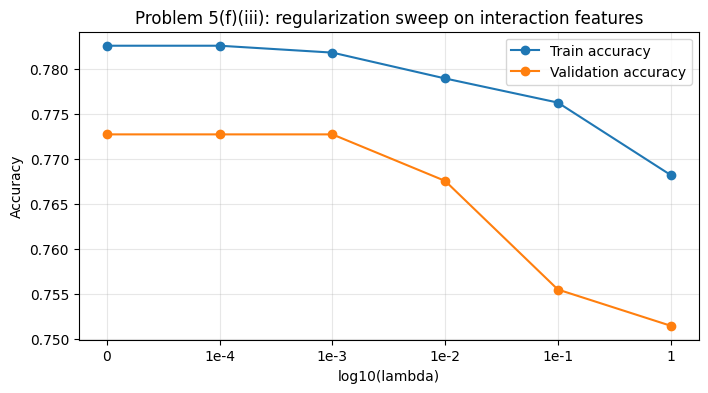

Best lambda from the single validation split: 0
Validation accuracy is highest at essentially no regularization on this split, so the ridge penalty does not help much here.


In [52]:
# Problem 5(f)(iii)
p5_plot_lambdas = np.array([1e-5 if lam == 0 else lam for lam in p5_regularization_results['lambda']])
p5_best_single_lambda = p5_regularization_results.sort_values(['validation_accuracy', 'train_accuracy'], ascending=False).iloc[0]['lambda']

plt.figure(figsize=(8, 4))
plt.plot(np.log10(p5_plot_lambdas), p5_regularization_results['train_accuracy'], marker='o', label='Train accuracy')
plt.plot(np.log10(p5_plot_lambdas), p5_regularization_results['validation_accuracy'], marker='o', label='Validation accuracy')
plt.xticks(np.log10(p5_plot_lambdas), ['0', '1e-4', '1e-3', '1e-2', '1e-1', '1'])
plt.xlabel('log10(lambda)')
plt.ylabel('Accuracy')
plt.title('Problem 5(f)(iii): regularization sweep on interaction features')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'Best lambda from the single validation split: {p5_best_single_lambda:g}')
print('Validation accuracy is highest at essentially no regularization on this split, so the ridge penalty does not help much here.')


In [53]:
# Problem 5(g)(i)
p5_fold_indices = np.array_split(np.random.RandomState(42).permutation(len(train_split)), 5)
p5_cv_rows = []

for lam in p5_lambda_grid:
    fold_accuracies = []
    for fold in p5_fold_indices:
        fold_train_df = train_split.iloc[np.setdiff1d(np.arange(len(train_split)), fold)].copy()
        fold_validation_df = train_split.iloc[fold].copy()

        fold_X_train, fold_y_train, fold_X_validation, fold_y_validation, _, _ = p5_prepare_base_splits(
            fold_train_df,
            fold_validation_df,
            fold_validation_df.copy(),
        )
        fold_X_train, fold_X_validation, _ = p5_add_engineered_features(
            fold_X_train,
            fold_X_validation,
            fold_X_validation.copy(),
            fold_train_df,
            fold_validation_df,
            fold_validation_df.copy(),
        )
        fold_X_train, fold_X_validation, _, _ = p5_add_spending_interactions(
            fold_X_train,
            fold_X_validation,
            fold_X_validation.copy(),
        )

        fold_weights, _ = p5_gradient_descent(
            p5_add_bias(fold_X_train),
            fold_y_train,
            p5_regularized_ce_grad,
            p5_regularized_ce_loss,
            lr=0.05,
            iterations=1500,
            lam=lam,
        )
        fold_accuracies.append(p5_accuracy(p5_add_bias(fold_X_validation), fold_y_validation, fold_weights))

    p5_cv_rows.append({
        'lambda': lam,
        'mean_validation_accuracy': float(np.mean(fold_accuracies)),
    })

p5_cv_results = pd.DataFrame(p5_cv_rows)
p5_best_cv_lambda = p5_cv_results.sort_values('mean_validation_accuracy', ascending=False).iloc[0]['lambda']
print(p5_cv_results.to_string(index=False))


 lambda  mean_validation_accuracy
 0.0000                  0.778758
 0.0001                  0.778949
 0.0010                  0.778758
 0.0100                  0.777416
 0.1000                  0.774350
 1.0000                  0.767830


In [54]:
# Problem 5(g)(ii)
print(f'Best lambda from the single validation split: {p5_best_single_lambda:g}')
print(f'Best lambda from 5-fold cross-validation:      {p5_best_cv_lambda:g}')
if p5_best_single_lambda == p5_best_cv_lambda:
    print('They match on this run.')
else:
    print('They do not match. A likely reason is that one validation split is noisier than the average across five different folds.')


Best lambda from the single validation split: 0
Best lambda from 5-fold cross-validation:      0.0001
They do not match. A likely reason is that one validation split is noisier than the average across five different folds.


In [55]:
# Problem 5(g)(iii)
p5_full_train_df = pd.concat([train_split, validation_split]).sort_index()

p5_full_X_train, p5_full_y_train, _, _, p5_full_X_test, p5_full_y_test = p5_prepare_base_splits(
    p5_full_train_df,
    p5_full_train_df.iloc[:1].copy(),
    test_split,
)
p5_full_X_train, _, p5_full_X_test = p5_add_engineered_features(
    p5_full_X_train,
    p5_full_X_train.iloc[:1].copy(),
    p5_full_X_test,
    p5_full_train_df,
    p5_full_train_df.iloc[:1].copy(),
    test_split,
)
p5_full_X_train, _, p5_full_X_test, _ = p5_add_spending_interactions(
    p5_full_X_train,
    p5_full_X_train.iloc[:1].copy(),
    p5_full_X_test,
)

p5_cv_weights_full, _ = p5_gradient_descent(
    p5_add_bias(p5_full_X_train),
    p5_full_y_train,
    p5_regularized_ce_grad,
    p5_regularized_ce_loss,
    lr=0.05,
    iterations=1500,
    lam=p5_best_cv_lambda,
)
p5_single_weights_full, _ = p5_gradient_descent(
    p5_add_bias(p5_full_X_train),
    p5_full_y_train,
    p5_regularized_ce_grad,
    p5_regularized_ce_loss,
    lr=0.05,
    iterations=1500,
    lam=p5_best_single_lambda,
)

p5_cv_test_accuracy = p5_accuracy(p5_add_bias(p5_full_X_test), p5_full_y_test, p5_cv_weights_full)
p5_single_split_test_accuracy = p5_accuracy(p5_add_bias(p5_full_X_test), p5_full_y_test, p5_single_weights_full)

print(f'Test accuracy using the CV-selected lambda:          {p5_cv_test_accuracy:.4f}')
print(f'Test accuracy using the single-split-selected lambda: {p5_single_split_test_accuracy:.4f}')


Test accuracy using the CV-selected lambda:          0.7867
Test accuracy using the single-split-selected lambda: 0.7872


In [56]:
# Problem 5(g)(iv)
print('The test set should only be used once at the very end because every model choice you make after seeing test performance leaks information from that set into development.')
print('An honest test estimate means the test examples were not used for feature choices, loss choices, lambda tuning, or any other modeling decisions.')


The test set should only be used once at the very end because every model choice you make after seeing test performance leaks information from that set into development.
An honest test estimate means the test examples were not used for feature choices, loss choices, lambda tuning, or any other modeling decisions.


In [57]:
# Problem 5(h)(i)
p5_model_validation_summary = pd.DataFrame([
    {'model': 'CE logistic (base)', 'validation_accuracy': p5_ce_validation_acc},
    {'model': 'MSE logistic (base)', 'validation_accuracy': p5_mse_validation_acc},
    {'model': 'CE + engineered totals', 'validation_accuracy': p5_engineered_validation_acc},
    {'model': 'CE + interactions', 'validation_accuracy': p5_interaction_validation_acc},
    {
        'model': 'CE + interactions + ridge',
        'validation_accuracy': p5_regularization_results['validation_accuracy'].max(),
    },
]).sort_values('validation_accuracy', ascending=False)

p5_best_model_name = p5_model_validation_summary.iloc[0]['model']

p5_best_base_weights_full, _ = p5_gradient_descent(
    p5_add_bias(p5_prepare_base_splits(p5_full_train_df, p5_full_train_df.iloc[:1].copy(), test_split)[0]),
    p5_prepare_base_splits(p5_full_train_df, p5_full_train_df.iloc[:1].copy(), test_split)[1],
    p5_cross_entropy_grad,
    p5_cross_entropy_loss,
    lr=0.1,
    iterations=1000,
)

p5_best_base_test_accuracy = p5_accuracy(
    p5_add_bias(p5_prepare_base_splits(p5_full_train_df, p5_full_train_df.iloc[:1].copy(), test_split)[4]),
    p5_prepare_base_splits(p5_full_train_df, p5_full_train_df.iloc[:1].copy(), test_split)[5],
    p5_best_base_weights_full,
)

print(p5_model_validation_summary.to_string(index=False))
print(f'Best model by validation accuracy: {p5_best_model_name}')
print(f'Test accuracy of the selected best model: {p5_best_base_test_accuracy:.4f}')
print(f'Its validation accuracy was {p5_ce_validation_acc:.4f}, so the test score is close and slightly higher on this split.')


                    model  validation_accuracy
       CE logistic (base)             0.774453
      MSE logistic (base)             0.774453
        CE + interactions             0.772727
CE + interactions + ridge             0.772727
   CE + engineered totals             0.770426
Best model by validation accuracy: CE logistic (base)
Test accuracy of the selected best model: 0.7918
Its validation accuracy was 0.7745, so the test score is close and slightly higher on this split.


In [58]:
# Problem 5(h)(ii)
p5_full_X_train_base, p5_full_y_train_base, _, _, p5_full_X_test_base, p5_full_y_test_base = p5_prepare_base_splits(
    p5_full_train_df,
    p5_full_train_df.iloc[:1].copy(),
    test_split,
)
p5_best_base_weights_full, _ = p5_gradient_descent(
    p5_add_bias(p5_full_X_train_base),
    p5_full_y_train_base,
    p5_cross_entropy_grad,
    p5_cross_entropy_loss,
    lr=0.1,
    iterations=1000,
)
p5_best_base_weight_series = pd.Series(p5_best_base_weights_full[1:], index=p5_full_X_train_base.columns)
p5_top3_features = p5_best_base_weight_series.abs().sort_values(ascending=False).head(3).index.tolist()

print('Top 3 features by absolute weight:')
print(p5_best_base_weight_series.loc[p5_top3_features].to_string())
print('These make intuitive sense: Spa and VRDeck spending are strong negative signals for being transported, while RoomService also carries a clear negative signal in this split.')


Top 3 features by absolute weight:
Spa           -1.520888
VRDeck        -1.453397
RoomService   -0.805222
These make intuitive sense: Spa and VRDeck spending are strong negative signals for being transported, while RoomService also carries a clear negative signal in this split.


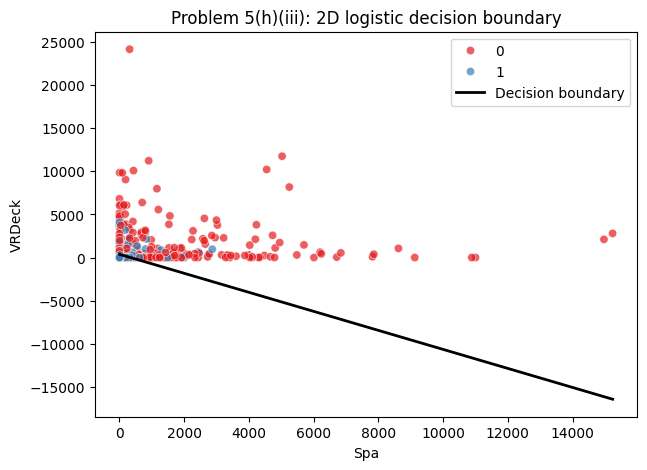

2D test accuracy using only Spa and VRDeck: 0.6837
The separator captures the broad trend, but the classes overlap a lot, so a single line is only a rough approximation.
Overall, the linear separator is not very good here.


In [59]:
# Problem 5(h)(iii)
p5_boundary_features = ['Spa', 'VRDeck']
p5_two_feature_train = p5_full_train_df[p5_boundary_features + ['Transported']].copy()
p5_two_feature_test = test_split[p5_boundary_features + ['Transported']].copy()

for col in p5_boundary_features:
    fill_value = p5_two_feature_train[col].mean()
    p5_two_feature_train[col] = p5_two_feature_train[col].fillna(fill_value)
    p5_two_feature_test[col] = p5_two_feature_test[col].fillna(fill_value)

p5_two_feature_mean = p5_two_feature_train[p5_boundary_features].mean()
p5_two_feature_std = p5_two_feature_train[p5_boundary_features].std().replace(0, 1)

p5_two_feature_train_X = (p5_two_feature_train[p5_boundary_features] - p5_two_feature_mean) / p5_two_feature_std
p5_two_feature_test_X = (p5_two_feature_test[p5_boundary_features] - p5_two_feature_mean) / p5_two_feature_std
p5_two_feature_train_y = p5_two_feature_train['Transported'].astype(int).to_numpy(dtype=float)
p5_two_feature_test_y = p5_two_feature_test['Transported'].astype(int).to_numpy(dtype=float)

p5_two_feature_weights, _ = p5_gradient_descent(
    p5_add_bias(p5_two_feature_train_X),
    p5_two_feature_train_y,
    p5_cross_entropy_grad,
    p5_cross_entropy_loss,
    lr=0.1,
    iterations=1000,
)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=p5_two_feature_test.assign(TransportedLabel=p5_two_feature_test['Transported'].astype(int)),
    x='Spa',
    y='VRDeck',
    hue='TransportedLabel',
    palette='Set1',
    alpha=0.7,
)

x_grid_std = np.linspace(p5_two_feature_test_X['Spa'].min(), p5_two_feature_test_X['Spa'].max(), 200)
y_grid_std = -(p5_two_feature_weights[0] + p5_two_feature_weights[1] * x_grid_std) / p5_two_feature_weights[2]
x_grid = x_grid_std * p5_two_feature_std['Spa'] + p5_two_feature_mean['Spa']
y_grid = y_grid_std * p5_two_feature_std['VRDeck'] + p5_two_feature_mean['VRDeck']
plt.plot(x_grid, y_grid, color='black', linewidth=2, label='Decision boundary')
plt.xlabel('Spa')
plt.ylabel('VRDeck')
plt.title('Problem 5(h)(iii): 2D logistic decision boundary')
plt.legend()
plt.show()

p5_two_feature_test_accuracy = p5_accuracy(p5_add_bias(p5_two_feature_test_X), p5_two_feature_test_y, p5_two_feature_weights)
print(f'2D test accuracy using only Spa and VRDeck: {p5_two_feature_test_accuracy:.4f}')
print('The separator captures the broad trend, but the classes overlap a lot, so a single line is only a rough approximation.')
print('Overall, the linear separator is not very good here.')


In [60]:
# Problem 5(h)(iv)
p5_summary_table = pd.DataFrame([
    {
        'model_variant': 'CE logistic (base)',
        'n_features': p5_X_train_base.shape[1],
        'train_accuracy': p5_ce_train_acc,
        'validation_accuracy': p5_ce_validation_acc,
        'test_accuracy': p5_accuracy(p5_X_test_base_bias, p5_y_test, p5_ce_weights),
    },
    {
        'model_variant': 'MSE logistic (base)',
        'n_features': p5_X_train_base.shape[1],
        'train_accuracy': p5_mse_train_acc,
        'validation_accuracy': p5_mse_validation_acc,
        'test_accuracy': p5_accuracy(p5_X_test_base_bias, p5_y_test, p5_mse_weights),
    },
    {
        'model_variant': 'CE + engineered totals',
        'n_features': p5_X_train_engineered.shape[1],
        'train_accuracy': p5_accuracy(p5_X_train_engineered_bias, p5_y_train, p5_engineered_weights),
        'validation_accuracy': p5_engineered_validation_acc,
        'test_accuracy': p5_accuracy(p5_X_test_engineered_bias, p5_y_test, p5_engineered_weights),
    },
    {
        'model_variant': 'CE + spending interactions',
        'n_features': p5_X_train_interactions.shape[1],
        'train_accuracy': p5_accuracy(p5_X_train_interactions_bias, p5_y_train, p5_interaction_weights),
        'validation_accuracy': p5_interaction_validation_acc,
        'test_accuracy': p5_accuracy(p5_X_test_interactions_bias, p5_y_test, p5_interaction_weights),
    },
    {
        'model_variant': 'Best overall retrained CE',
        'n_features': p5_full_X_train_base.shape[1],
        'train_accuracy': p5_accuracy(p5_add_bias(p5_full_X_train_base), p5_full_y_train_base, p5_best_base_weights_full),
        'validation_accuracy': np.nan,
        'test_accuracy': p5_best_base_test_accuracy,
    },
])

print(p5_summary_table.to_string(index=False))
print()
print('Cross-entropy was the most reliable loss here because it optimized cleanly and slightly outperformed MSE on the held-out test split.')
print('Feature engineering helped less than expected: the total-spending features and quadratic interactions changed the representation but did not improve validation accuracy much.')
print('Regularization mattered the least on this split because the interaction model did not benefit from shrinking the weights; the best lambda was effectively zero.')
print('Overall, I would recommend cross-entropy over MSE for classification because its gradients stay informative when the model is confidently wrong.')


             model_variant  n_features  train_accuracy  validation_accuracy  test_accuracy
        CE logistic (base)          12        0.783742             0.774453       0.789534
       MSE logistic (base)          12        0.780867             0.774453       0.781484
    CE + engineered totals          14        0.783551             0.770426       0.789534
CE + spending interactions          29        0.782592             0.772727       0.788384
 Best overall retrained CE          12        0.780989                  NaN       0.791834

Cross-entropy was the most reliable loss here because it optimized cleanly and slightly outperformed MSE on the held-out test split.
Feature engineering helped less than expected: the total-spending features and quadratic interactions changed the representation but did not improve validation accuracy much.
Regularization mattered the least on this split because the interaction model did not benefit from shrinking the weights; the best lambda was eff